In [1]:
import pandas as pd

df = pd.read_csv("sensitivity.csv")
tags = pd.read_csv("Games Sales Curve Categorizations - tags.csv")

In [2]:
df

,Unnamed: 0,product,Weeks_from_Release,units,percent_of_max
0,0,A Memoir Blue,1.0,2367,0.064988
1,1,A Memoir Blue,2.0,3038,0.083411
2,2,A Memoir Blue,3.0,3543,0.097276
3,3,A Memoir Blue,4.0,3902,0.107133
4,4,A Memoir Blue,5.0,4212,0.115644
...,...,...,...,...,...
7721,7721,What Remains of Edith Finch,419.0,2522393,0.997878
7722,7722,What Remains of Edith Finch,420.0,2524222,0.998602
7723,7723,What Remains of Edith Finch,421.0,2525581,0.999139
7724,7724,What Remains of Edith Finch,422.0,2527753,0.999998


In [3]:
one_year = df.query("Weeks_from_Release <=52")
six_months = df.query("Weeks_from_Release <=26")

LT = df

In [4]:
#df = df.drop_duplicates('product', keep='last')
LT = LT.drop_duplicates('product', keep='last')
one_year = one_year.drop_duplicates('product', keep='last')
six_months = six_months.drop_duplicates('product', keep='last')

In [5]:
data = LT.merge(tags, on='product')
data_one_year = one_year.merge(tags, on='product')
data_six_months = six_months.merge(tags, on='product')
data_LT = LT.merge(tags, on='product')


In [6]:
data = data.fillna("")

In [7]:
import ast
data['curve_category'] = data['curve_category'].apply(lambda x: x.split(', '))

In [8]:
cat_df = data.explode('curve_category')

In [9]:
cat_df.groupby("curve_category").units.describe().round(0)/1000

,count,mean,std,min,25%,50%,75%,max
curve_category,,,,,,,,
,0.004,39.345,21.159,20.063,27.516,34.130,45.960,69.057
front-loaded,0.018,534.992,1506.179,8.896,58.581,131.914,305.344,6532.124
high perf,0.005,3014.530,2105.445,1127.493,1769.530,2527.757,3115.748,6532.124
linear,0.015,768.462,1000.730,12.079,50.248,178.281,1176.948,3115.748
low perf,0.012,41.233,28.207,8.896,13.317,40.040,64.473,92.877
no-presale,0.018,226.232,318.610,8.896,23.426,67.260,341.032,1127.493
presale,0.015,1169.354,1766.300,56.837,153.396,313.122,1497.966,6532.124
secondary-surge,0.010,633.253,1020.790,8.896,66.858,123.968,534.764,3115.748


In [10]:
data_one_year.rename({'Weeks_from_Release':'Weeks_from_Release_first_year', 'units':'units_first_year'},axis=1, inplace=True)
data_one_year = data_one_year[['product', 'Weeks_from_Release_first_year', 'units_first_year']]

data_one_year

,product,Weeks_from_Release_first_year,units_first_year
0,A Memoir Blue,52.0,16713
1,Ashen,52.0,192533
2,Cocoon,52.0,226649
3,Donut County,52.0,191425
4,Due Process,52.0,135839
5,Flock,46.0,8896
6,Florence,52.0,224461
7,Flower,52.0,50270
8,Gorogoa,52.0,199062
9,Hindsight,52.0,6330


In [11]:
data_six_months.rename({'Weeks_from_Release':'Weeks_from_Release_6month', 'units':'units_6month'},axis=1, inplace=True)
data_six_months = data_six_months[['product', 'Weeks_from_Release_6month', 'units_6month']]
data_six_months

,product,Weeks_from_Release_6month,units_6month
0,A Memoir Blue,26.0,11029
1,Ashen,26.0,152208
2,Cocoon,26.0,166944
3,Donut County,26.0,139824
4,Due Process,26.0,111927
5,Flock,26.0,7347
6,Florence,26.0,160918
7,Flower,26.0,31888
8,Gorogoa,26.0,105436
9,Hindsight,26.0,3652


In [12]:
data_LT.rename({'Weeks_from_Release':'Weeks_from_Release_LT', 'units':'units_LT'},axis=1, inplace=True)

final  = data_LT.merge(data_six_months, on='product')
final  = final.merge(data_one_year, on='product')

In [13]:
final['first_year_ratio'] = final['units_first_year'] / final['units_LT']
final['first_6month_ratio'] = final['units_6month'] / final['units_LT']
final['6month_to_year'] = final['units_6month'] / final['units_first_year']
final['diff_between_year'] = final['first_6month_ratio'] - final['first_year_ratio']

In [14]:
final[['product', 'units_LT','units_first_year','units_6month','first_year_ratio','first_6month_ratio','6month_to_year','diff_between_year']].sort_values("first_year_ratio", ascending=False)

,product,units_LT,units_first_year,units_6month,first_year_ratio,first_6month_ratio,6month_to_year,diff_between_year
5,Flock,8896,8896,7347,1.000000,0.825877,0.825877,-0.174123
34,Wanderstop,69057,69057,69057,1.000000,1.000000,1.000000,0.000000
24,Skin Deep,20063,20063,20063,1.000000,1.000000,1.000000,0.000000
17,Lushfoil Photography Sim,38261,38261,38261,1.000000,1.000000,1.000000,0.000000
16,Lorelei and the Laser Eyes,101224,100548,46367,0.993322,0.458063,0.461143,-0.535258
21,Open Roads,19094,18073,14529,0.946528,0.760920,0.803906,-0.185608
4,Due Process,160082,135839,111927,0.848559,0.699185,0.823968,-0.149373
32,Thirsty Suitors,13267,11186,8487,0.843145,0.639708,0.758716,-0.203437
2,Cocoon,282008,226649,166944,0.803697,0.591983,0.736575,-0.211714
26,Storyteller,573482,457589,276270,0.797913,0.481741,0.603751,-0.316172


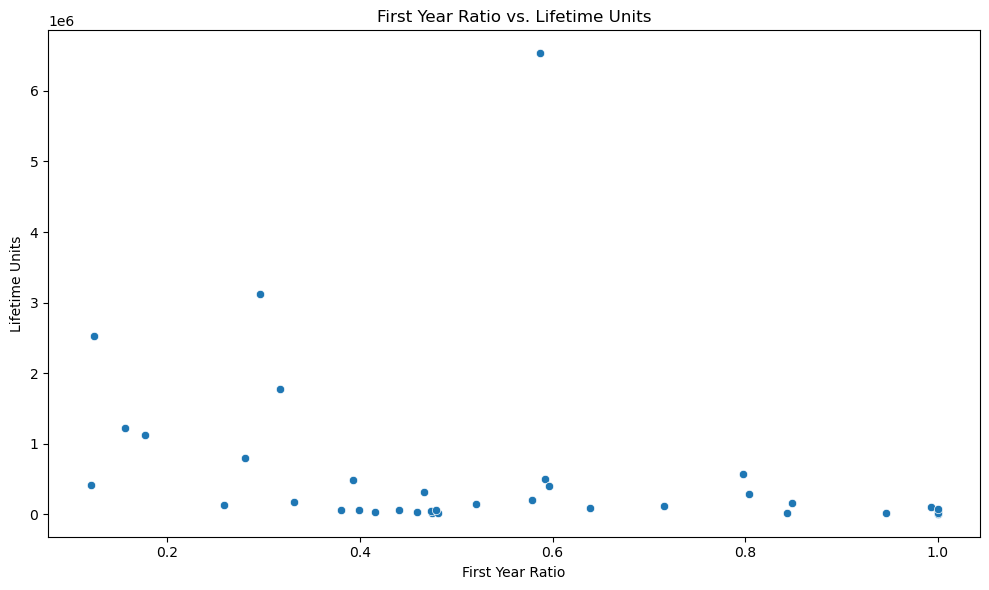

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=final, x='first_year_ratio', y='units_LT')

# Add labels and title
plt.xlabel('First Year Ratio')
plt.ylabel('Lifetime Units')
plt.title('First Year Ratio vs. Lifetime Units')

plt.tight_layout()
plt.show()

In [16]:
final = final.fillna("")

In [17]:
final['curve_category'] = final['curve_category'].apply(lambda x: x.split(', '))

In [18]:
final_tags = final.explode('curve_category')

In [19]:
final_tags.groupby("curve_category").first_year_ratio.mean()

curve_category
                   0.854025
front-loaded       0.682353
high perf          0.299965
linear             0.319180
low perf           0.584657
no-presale         0.529583
presale            0.495898
secondary-surge    0.534488
Name: first_year_ratio, dtype: float64